# Laboratorio 5 — Clasificación de tweets usando minería de texto

**Universidad del Valle de Guatemala** · Facultad de Ingeniería · Departamento de Ciencias de la Computación
**CC3084 — Data Science** · Semestre II – 2026

**Entrega:** Avance (descripción de los datos, preprocesamiento, unigramas, bigramas y modelo preliminar de clasificación)

**Dataset:** [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/c/nlp-getting-started) (Kaggle)

**Objetivo del laboratorio:** construir un clasificador que determine si un tweet se refiere a un desastre real (`target = 1`) o no (`target = 0`).


## 1. Carga de librerías y datos

Se utilizan las siguientes librerías de Python:

- **pandas / numpy**: manipulación de datos.
- **matplotlib / seaborn**: visualización.
- **nltk**: stopwords y tokenización.
- **wordcloud**: nube de palabras.
- **scikit-learn**: vectorización (TF-IDF, `CountVectorizer` para n-gramas) y modelos de clasificación.
- **re / string**: limpieza de texto con expresiones regulares.


In [1]:
import re
import string
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

RANDOM_STATE = 42


In [2]:
df = pd.read_csv("data/train.csv")
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()


Dimensiones del dataset: 7613 filas x 5 columnas


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


## 2. Descripción general de los datos

El dataset contiene `id`, `keyword`, `location`, `text` y `target`. Revisamos tipos de datos, valores nulos y el balance de la variable objetivo antes de cualquier preprocesamiento.


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 297.5 KB


In [4]:
missing = df.isna().sum().to_frame("valores_nulos")
missing["% del total"] = (missing["valores_nulos"] / len(df) * 100).round(2)
missing


,valores_nulos,% del total
id,0,0.00
keyword,61,0.80
location,2533,33.27
text,0,0.00
target,0,0.00


**Observaciones sobre valores nulos:**

- `keyword` tiene muy pocos nulos (~0.8%): se puede imputar con una categoría `"sin_keyword"` o simplemente ignorarse en el texto libre.
- `location` tiene una proporción alta de nulos (~33%) y además es texto libre no normalizado (ciudades, países, ubicaciones inventadas como "Earth" o "everywhere"), por lo que **no se usará como predictor directo** en esta etapa; su valor real estaría en un procesamiento de geolocalización que excede el alcance de este laboratorio.
- `text` y `target` no tienen nulos: son las columnas centrales del análisis.


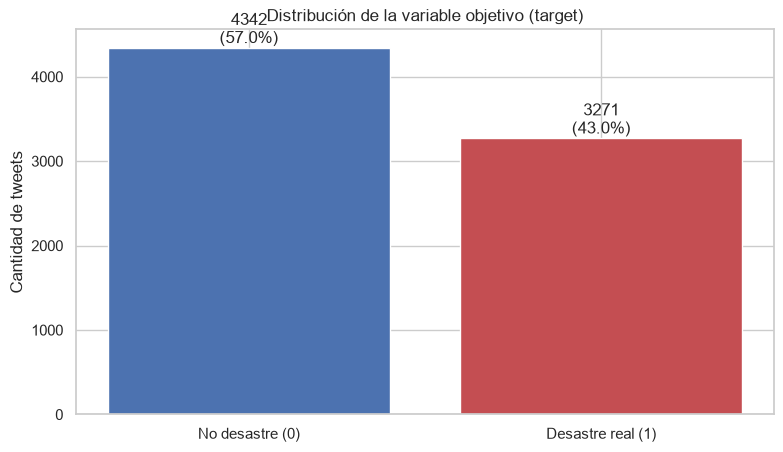

target
0    4342
1    3271
Name: count, dtype: int64


In [5]:
target_counts = df["target"].value_counts().sort_index()
target_pct = (target_counts / len(df) * 100).round(1)

fig, ax = plt.subplots()
bars = ax.bar(["No desastre (0)", "Desastre real (1)"], target_counts.values,
              color=["#4C72B0", "#C44E52"])
for bar, pct in zip(bars, target_pct.values):
    ax.annotate(f"{bar.get_height()}\n({pct}%)", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom")
ax.set_ylabel("Cantidad de tweets")
ax.set_title("Distribución de la variable objetivo (target)")
plt.show()

print(target_counts)


**Balance de clases:** el dataset está moderadamente desbalanceado (~57% no-desastre vs. ~43% desastre real), pero no de forma extrema. Se tomará en cuenta al evaluar los modelos (usar métricas como *precision*, *recall* y *F1*, no solo *accuracy*, y aplicar `stratify` en el split de entrenamiento/prueba).


C:\Users\Gabriel\AppData\Local\Temp\ipykernel_18624\1112829799.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=keyword_counts.values, y=keyword_counts.index, ax=ax, palette="viridis")


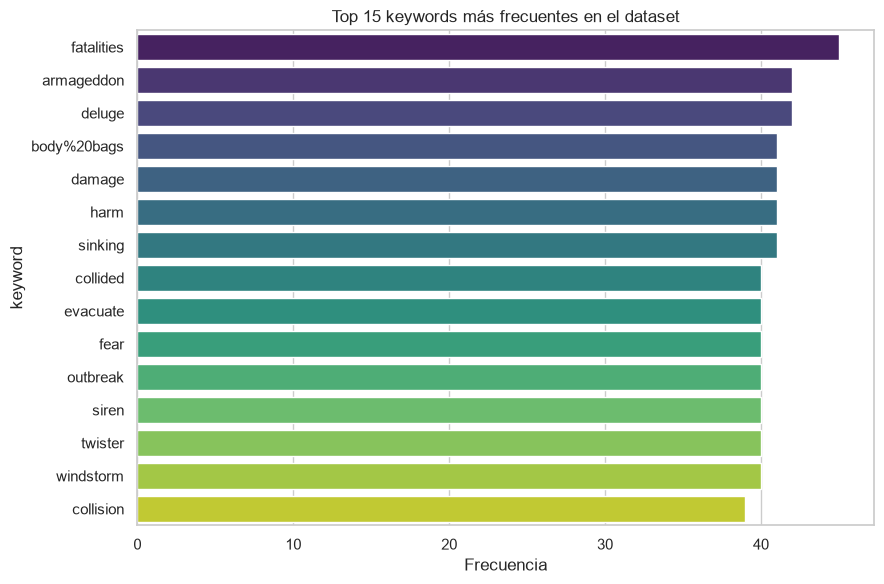

In [6]:
keyword_counts = df["keyword"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=keyword_counts.values, y=keyword_counts.index, ax=ax, palette="viridis")
ax.set_xlabel("Frecuencia")
ax.set_title("Top 15 keywords más frecuentes en el dataset")
plt.tight_layout()
plt.show()


In [7]:
disaster_rate_by_keyword = (
    df.dropna(subset=["keyword"])
      .groupby("keyword")["target"]
      .agg(["mean", "count"])
      .rename(columns={"mean": "tasa_desastre", "count": "n_tweets"})
)

print("Keywords MÁS asociadas a desastre real:")
print(disaster_rate_by_keyword[disaster_rate_by_keyword["n_tweets"] >= 10].sort_values("tasa_desastre", ascending=False).head(10))

print("\nKeywords MENOS asociadas a desastre real:")
print(disaster_rate_by_keyword[disaster_rate_by_keyword["n_tweets"] >= 10].sort_values("tasa_desastre", ascending=True).head(10))


Keywords MÁS asociadas a desastre real:
                   tasa_desastre  n_tweets
keyword                                   
debris                  1.000000        37
derailment              1.000000        39
wreckage                1.000000        39
outbreak                0.975000        40
oil%20spill             0.973684        38
typhoon                 0.973684        38
suicide%20bombing       0.969697        33
suicide%20bomber        0.967742        31
bombing                 0.931034        29
suicide%20bomb          0.914286        35

Keywords MENOS asociadas a desastre real:
             tasa_desastre  n_tweets
keyword                             
aftershock        0.000000        34
body%20bags       0.024390        41
ruin              0.027027        37
blazing           0.029412        34
body%20bag        0.030303        33
electrocute       0.031250        32
screaming         0.055556        36
traumatised       0.057143        35
panicking         0.060606     

**Observación:** existen keywords casi perfectamente asociadas a una clase (p. ej. `debris`, `wreckage`, `derailment` casi siempre son desastre real; `aftershock` casi nunca lo es a pesar del nombre). Esto sugiere que `keyword`, aunque no es el foco del análisis de texto libre, **podría usarse como variable auxiliar** en el modelo final.


## 3. Limpieza y preprocesamiento del texto

Los tweets son texto ruidoso: contienen URLs, menciones (`@usuario`), hashtags, entidades HTML (`&amp;`), emojis, errores de codificación (mojibake) y puntuación. Se documenta cada paso por separado para poder justificar las decisiones tomadas, tal como pide el enunciado.

Se muestran ejemplos reales del propio dataset para justificar cada regla.


In [8]:
ejemplos = [
    df[df["text"].str.contains("http", na=False)]["text"].iloc[0],
    df[df["text"].str.contains("&amp;", na=False)]["text"].iloc[0],
    df[df["text"].str.contains("911", na=False)]["text"].iloc[1],
]
for e in ejemplos:
    print("-", e)


- @bbcmtd Wholesale Markets ablaze http://t.co/lHYXEOHY6C
- Rene Ablaze &amp; Jacinta - Secret 2k13 (Fallen Skies Edit) - Mar 30 2013  https://t.co/7MLMsUzV1Z
- Came across this fire video not mine..enjoy..#fire #firemen #firetruck #emergency #rescue #911 #summertime #sirensÛ_ http://t.co/hcYAJsAcfJ


### 3.1. Pasos de limpieza aplicados y justificación

1. **Minúsculas**: se normaliza todo el texto a minúsculas para que `Fire`, `FIRE` y `fire` se traten como el mismo token.
2. **Entidades HTML** (`&amp;`, `&lt;`, `&gt;`, `&quot;`): Twitter codifica caracteres especiales como entidades HTML; se decodifican a su símbolo real (p. ej. `&amp;` → `&`) antes de continuar.
3. **URLs**: se eliminan por completo (`http://...`, `https://...`, `www...`). No aportan información semántica sobre el contenido del tweet y son casi únicas por tweet, por lo que solo añadirían ruido/dimensionalidad al vocabulario.
4. **Menciones (`@usuario`)**: se eliminan. El nombre de usuario mencionado no aporta señal sobre si el tweet describe un desastre real.
5. **Símbolo de hashtag (`#`)**: se elimina el símbolo pero **se conserva la palabra** (`#earthquake` → `earthquake`), ya que el término dentro del hashtag sí es relevante para la clasificación.
6. **Emojis y emoticones**: se eliminan en esta etapa de limpieza para el modelo de bag-of-words / TF-IDF. *Nota:* en la sección de análisis de sentimiento (entrega final) se evaluará si conservarlos aporta señal adicional, ya que un emoji como 😢 o 🔥 podría ser informativo del tono del tweet.
7. **Caracteres de codificación corrupta (mojibake)** como `\x89Û_`: se eliminan junto con cualquier carácter no imprimible/no-ASCII, ya que corresponden a errores de encoding de comillas/apóstrofes y no a información útil.
8. **Puntuación y caracteres especiales**: se eliminan los signos de puntuación (`.`, `,`, `!`, `?`, `'`, `"`, etc.).
9. **Espacios múltiples**: se colapsan a un solo espacio y se recortan los extremos.
10. **Números**: se decidió **conservarlos** en lugar de eliminarlos. La razón es el propio caso mencionado en el enunciado: `911` es un token con fuerte señal de emergencia real; eliminar todos los números perdería esa información. Se filtrarán después, en la etapa de modelado, solo si el análisis de frecuencias muestra que no aportan valor discriminativo.
11. **Tokenización**: se separa el texto limpio en palabras individuales usando `nltk.word_tokenize`.
12. **Stopwords**: se eliminan artículos, preposiciones y conjunciones en inglés (dataset en inglés) usando la lista de `nltk.corpus.stopwords`, ya que son palabras de altísima frecuencia en ambas clases y no ayudan a discriminar entre desastre real o no.


In [9]:
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

stop_words = set(stopwords.words("english"))
print(f"Cantidad de stopwords en inglés: {len(stop_words)}")
print(sorted(list(stop_words))[:15])


Cantidad de stopwords en inglés: 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't"]


In [10]:
URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
HASHTAG_SYMBOL_RE = re.compile(r"#")
HTML_ENTITIES = {
    "&amp;": "&", "&lt;": "<", "&gt;": ">", "&quot;": '"', "&#39;": "'",
}
EMOJI_RE = re.compile(
    "["
    "\U0001F300-\U0001FAFF"  # símbolos, pictogramas, emoticones, transporte
    "\U00002600-\U000027BF"  # símbolos diversos y dingbats
    "\U0001F1E0-\U0001F1FF"  # banderas
    "]+", flags=re.UNICODE
)
NON_ASCII_RE = re.compile(r"[^\x00-\x7F]+")
PUNCT_TABLE = str.maketrans("", "", string.punctuation)
MULTI_SPACE_RE = re.compile(r"\s+")


def decode_html_entities(text):
    for entity, char in HTML_ENTITIES.items():
        text = text.replace(entity, char)
    return text


def clean_text(text, keep_numbers=True):
    text = text.lower()
    text = decode_html_entities(text)
    text = URL_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    text = HASHTAG_SYMBOL_RE.sub("", text)      # quita '#' pero deja la palabra
    text = EMOJI_RE.sub(" ", text)
    text = NON_ASCII_RE.sub(" ", text)          # limpia mojibake / restos de encoding
    text = text.translate(PUNCT_TABLE)          # quita puntuación
    if not keep_numbers:
        text = re.sub(r"\d+", " ", text)
    text = MULTI_SPACE_RE.sub(" ", text).strip()
    return text


def tokenize_and_remove_stopwords(text):
    tokens = word_tokenize(text)
    return [t for t in tokens if t not in stop_words and len(t) > 1]


In [11]:
# Demostración del pipeline paso a paso sobre ejemplos reales del dataset
demo = df["text"].iloc[[0, 3, 9]].tolist() + [
    df[df["text"].str.contains("&amp;", na=False)]["text"].iloc[0]
]

for original in demo:
    limpio = clean_text(original)
    tokens = tokenize_and_remove_stopwords(limpio)
    print("ORIGINAL :", original)
    print("LIMPIO   :", limpio)
    print("TOKENS   :", tokens)
    print("-" * 100)


ORIGINAL : Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
LIMPIO   : our deeds are the reason of this earthquake may allah forgive us all
TOKENS   : ['deeds', 'reason', 'earthquake', 'may', 'allah', 'forgive', 'us']
----------------------------------------------------------------------------------------------------
ORIGINAL : 13,000 people receive #wildfires evacuation orders in California 
LIMPIO   : 13000 people receive wildfires evacuation orders in california
TOKENS   : ['13000', 'people', 'receive', 'wildfires', 'evacuation', 'orders', 'california']
----------------------------------------------------------------------------------------------------
ORIGINAL : I'm afraid that the tornado is coming to our area...
LIMPIO   : im afraid that the tornado is coming to our area
TOKENS   : ['im', 'afraid', 'tornado', 'coming', 'area']
----------------------------------------------------------------------------------------------------
ORIGINAL : Rene Ablaze &amp; Jaci

In [12]:
df["clean_text"] = df["text"].apply(clean_text)
df["tokens"] = df["clean_text"].apply(tokenize_and_remove_stopwords)
df["clean_text_no_stop"] = df["tokens"].apply(lambda toks: " ".join(toks))

df[["text", "clean_text", "clean_text_no_stop"]].head(10)


,text,clean_text,clean_text_no_stop
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...,deeds reason earthquake may allah forgive us
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...,residents asked shelter place notified officer...
3,"13,000 people receive #wildfires evacuation or...",13000 people receive wildfires evacuation orde...,13000 people receive wildfires evacuation orde...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...,got sent photo ruby alaska smoke wildfires pou...
5,#RockyFire Update => California Hwy. 20 closed...,rockyfire update california hwy 20 closed in b...,rockyfire update california hwy 20 closed dire...
6,#flood #disaster Heavy rain causes flash flood...,flood disaster heavy rain causes flash floodin...,flood disaster heavy rain causes flash floodin...
7,I'm on top of the hill and I can see a fire in...,im on top of the hill and i can see a fire in ...,im top hill see fire woods
8,There's an emergency evacuation happening now ...,theres an emergency evacuation happening now i...,theres emergency evacuation happening building...
9,I'm afraid that the tornado is coming to our a...,im afraid that the tornado is coming to our area,im afraid tornado coming area


Con esto, cada tweet ahora cuenta con:

- `clean_text`: texto limpio (minúsculas, sin URLs/menciones/emojis/puntuación) pero **con stopwords**, útil para vectorizadores que ya filtran stopwords internamente (p. ej. `TfidfVectorizer(stop_words="english")`).
- `tokens` / `clean_text_no_stop`: versión tokenizada **sin stopwords**, usada para los análisis de frecuencia, n-gramas y nube de palabras.


## 4. Frecuencia de palabras (unigramas)

Se calcula la frecuencia de palabras por separado para tweets de desastre real (`target = 1`) y de no-desastre (`target = 0`), para identificar qué términos son característicos de cada clase.


In [13]:
def word_freq(tokens_series, top_n=20):
    counter = Counter()
    for tokens in tokens_series:
        counter.update(tokens)
    return counter.most_common(top_n)


freq_disaster = word_freq(df.loc[df["target"] == 1, "tokens"])
freq_no_disaster = word_freq(df.loc[df["target"] == 0, "tokens"])

print("Top 20 palabras — DESASTRE REAL (target=1):")
for w, c in freq_disaster:
    print(f"  {w:<15} {c}")

print("\nTop 20 palabras — NO DESASTRE (target=0):")
for w, c in freq_no_disaster:
    print(f"  {w:<15} {c}")


Top 20 palabras — DESASTRE REAL (target=1):
  fire            180
  news            135
  via             121
  disaster        118
  california      111
  suicide         110
  police          107
  people          105
  killed          93
  like            92
  hiroshima       87
  crash           85
  fires           85
  storm           85
  us              81
  families        81
  train           79
  emergency       76
  buildings       76
  bomb            75

Top 20 palabras — NO DESASTRE (target=0):
  like            253
  im              244
  new             171
  get             163
  dont            141
  one             129
  body            113
  via             99
  would           97
  video           96
  got             92
  people          91
  love            90
  know            85
  back            84
  us              83
  time            82
  see             82
  full            82
  cant            81


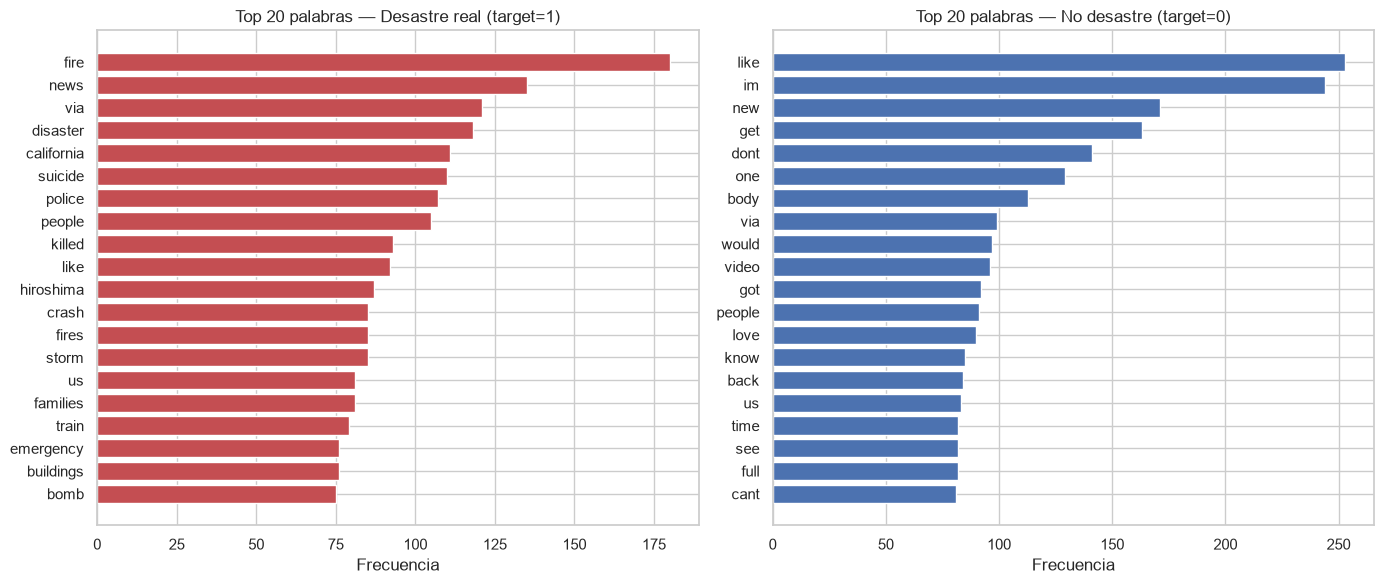

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

words1, counts1 = zip(*freq_disaster)
axes[0].barh(words1[::-1], counts1[::-1], color="#C44E52")
axes[0].set_title("Top 20 palabras — Desastre real (target=1)")
axes[0].set_xlabel("Frecuencia")

words0, counts0 = zip(*freq_no_disaster)
axes[1].barh(words0[::-1], counts0[::-1], color="#4C72B0")
axes[1].set_title("Top 20 palabras — No desastre (target=0)")
axes[1].set_xlabel("Frecuencia")

plt.tight_layout()
plt.show()


In [15]:
set_disaster = set(w for w, _ in freq_disaster)
set_no_disaster = set(w for w, _ in freq_no_disaster)
comunes = set_disaster & set_no_disaster
print(f"Palabras en el top 20 de AMBAS categorías ({len(comunes)}): {comunes}")


Palabras en el top 20 de AMBAS categorías (4): {'us', 'via', 'like', 'people'}


**Discusión:**

- Palabras como `like`, `new`, `via`, `get` aparecen frecuentes en ambas categorías: son términos genéricos de Twitter sin carga semántica sobre desastres, por lo que **aportan poco poder discriminativo** por sí solas y son candidatas a tratarse casi como stopwords adicionales del dominio.
- Palabras específicas de la clase 1 como `fire`, `california`, `suicide`, `killed`, `flood`, `storm`, `bomb`, `disaster` sí parecen tener alto valor discriminativo: describen eventos concretos de desastre o violencia.
- La clase 0 muestra palabras de uso coloquial/figurado (`love`, `body`, `full`, `people`, `time`) que corresponden a usos metafóricos de palabras clave (p. ej. "ablaze" usado como "me encanta" y no como incendio real), lo cual confirma la importancia del **contexto** y no solo de palabras sueltas.
- **Sí vale la pena explorar bigramas/trigramas**: muchas palabras clave del dataset (`suicide bomb`, `forest fire`, `oil spill`) solo cobran su significado real de desastre cuando se analizan en combinación con la palabra siguiente/anterior; un unigrama aislado como "bomb" no distingue "bomb threat" (desastre) de "the bomb" (jerga positiva).


## 5. Nube de palabras

Se genera una nube de palabras por cada clase para visualizar de forma intuitiva los términos más frecuentes.


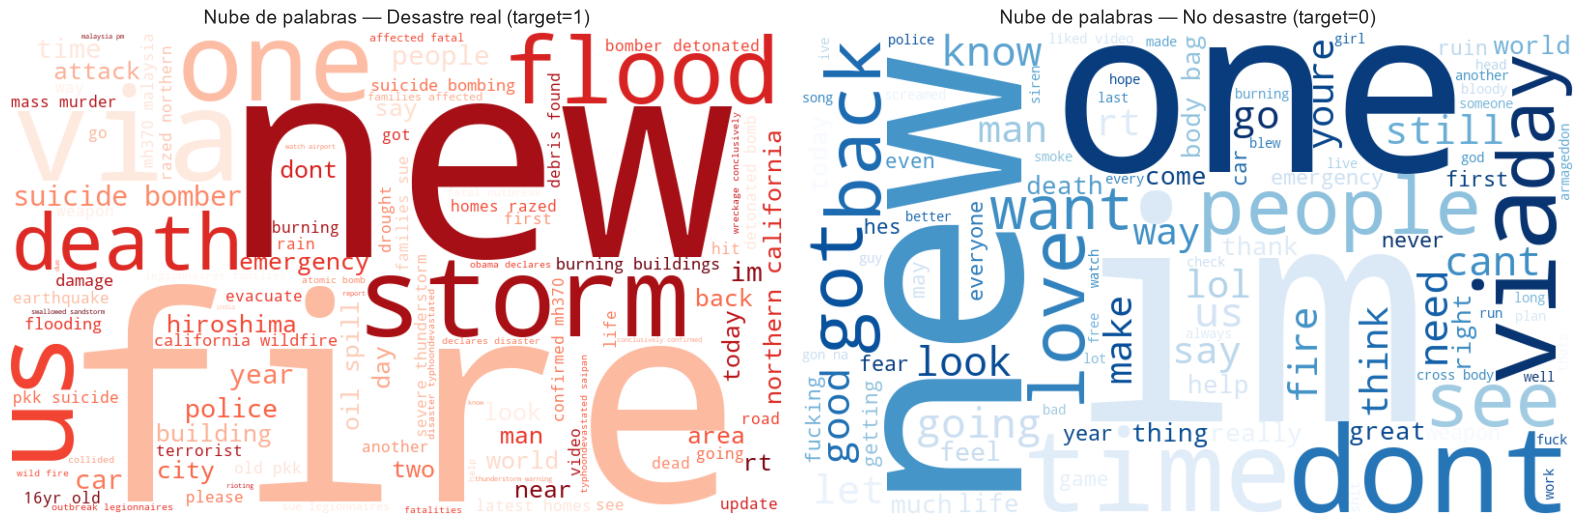

In [16]:
text_disaster = " ".join(df.loc[df["target"] == 1, "clean_text_no_stop"])
text_no_disaster = " ".join(df.loc[df["target"] == 0, "clean_text_no_stop"])

wc_disaster = WordCloud(width=800, height=500, background_color="white",
                         colormap="Reds", max_words=100).generate(text_disaster)
wc_no_disaster = WordCloud(width=800, height=500, background_color="white",
                            colormap="Blues", max_words=100).generate(text_no_disaster)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(wc_disaster, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Nube de palabras — Desastre real (target=1)", fontsize=14)

axes[1].imshow(wc_no_disaster, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Nube de palabras — No desastre (target=0)", fontsize=14)

plt.tight_layout()
plt.show()


## 6. Bigramas

Se generan bigramas con `CountVectorizer(ngram_range=(2,2))` sobre el texto ya limpio (sin stopwords) para capturar contexto que los unigramas no reflejan.


In [17]:
def top_ngrams(corpus, ngram_range=(2, 2), top_n=15):
    vec = CountVectorizer(ngram_range=ngram_range)
    X = vec.fit_transform(corpus)
    freqs = np.asarray(X.sum(axis=0)).ravel()
    vocab = vec.get_feature_names_out()
    pairs = sorted(zip(vocab, freqs), key=lambda x: x[1], reverse=True)
    return pairs[:top_n]


bigrams_disaster = top_ngrams(df.loc[df["target"] == 1, "clean_text_no_stop"])
bigrams_no_disaster = top_ngrams(df.loc[df["target"] == 0, "clean_text_no_stop"])

print("Top 15 bigramas — DESASTRE REAL:")
for bg, c in bigrams_disaster:
    print(f"  {bg:<25} {c}")

print("\nTop 15 bigramas — NO DESASTRE:")
for bg, c in bigrams_no_disaster:
    print(f"  {bg:<25} {c}")


Top 15 bigramas — DESASTRE REAL:
  suicide bomber            59
  northern california       41
  oil spill                 38
  burning buildings         36
  california wildfire       34
  suicide bombing           34
  70 years                  30
  bomber detonated          30
  confirmed mh370           29
  homes razed               29
  16yr old                  28
  detonated bomb            28
  latest homes              28
  pkk suicide               28
  razed northern            28

Top 15 bigramas — NO DESASTRE:
  cross body                38
  liked video               34
  gon na                    32
  wan na                    30
  full read                 28
  body bag                  27
  body bagging              23
  burning buildings         23
  body bags                 21
  looks like                21
  quarantine offensive      21
  reddit quarantine         21
  content policy            20
  feel like                 20
  offensive content         20


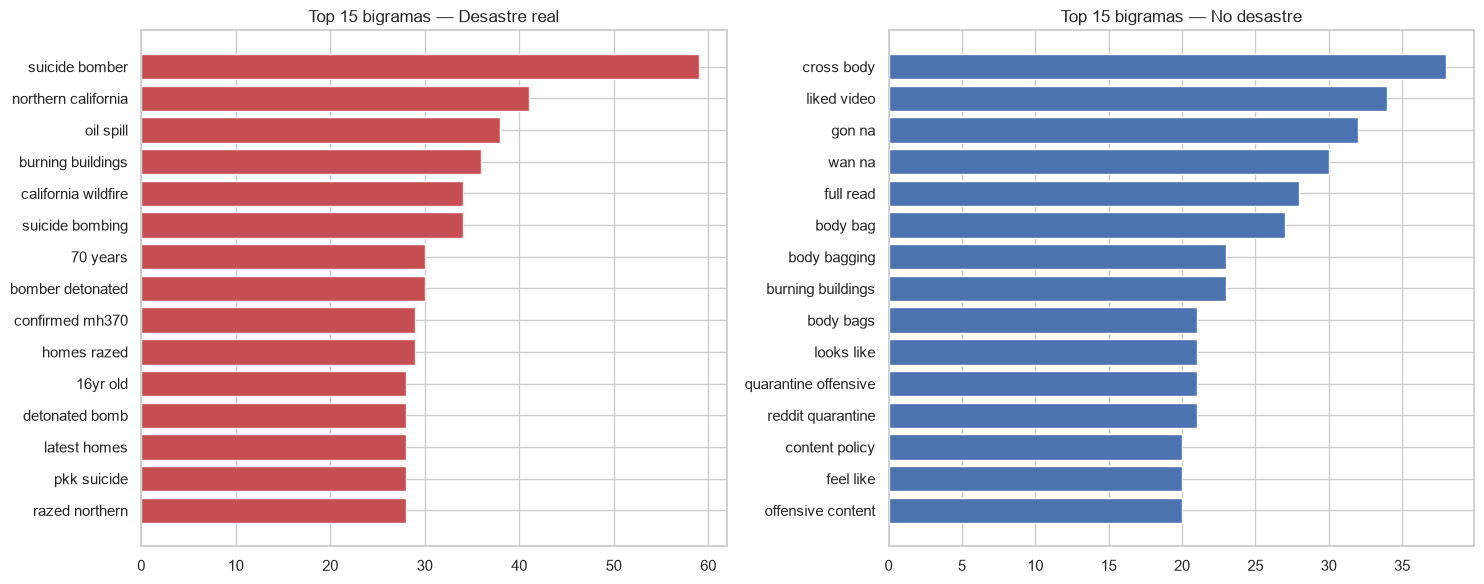

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bg1, c1 = zip(*bigrams_disaster)
axes[0].barh(bg1[::-1], c1[::-1], color="#C44E52")
axes[0].set_title("Top 15 bigramas — Desastre real")

bg0, c0 = zip(*bigrams_no_disaster)
axes[1].barh(bg0[::-1], c0[::-1], color="#4C72B0")
axes[1].set_title("Top 15 bigramas — No desastre")

plt.tight_layout()
plt.show()


**Discusión:** los bigramas de la clase de desastre real (`suicide bomber`, `northern california`, `oil spill`, `california wildfire`) son mucho más específicos y accionables que los unigramas equivalentes, confirmando que **el contexto de dos palabras reduce la ambigüedad** de términos que por sí solos son polisémicos (p. ej. "bomb" vs. "suicide bomber"). Por esta razón, el modelo de clasificación probará representaciones que incluyan unigramas + bigramas (`ngram_range=(1,2)`) y no solo unigramas.


## 7. Modelo preliminar de clasificación

Como primer acercamiento (a refinar en la entrega final) se entrena un modelo base con:

- **Vectorización**: TF-IDF sobre `clean_text` (dejamos que el propio vectorizador filtre stopwords en inglés y probamos unigramas + bigramas para capturar el contexto discutido arriba).
- **División train/test**: 80% / 20%, estratificada por `target` para mantener el balance de clases.
- **Algoritmos**: Regresión Logística y Naive Bayes Multinomial, dos baselines estándar y rápidos para clasificación de texto, que se compararán con métricas de *accuracy*, *precision*, *recall* y *F1-score* (más informativas que solo accuracy dado el ligero desbalance de clases).


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["target"],
    test_size=0.2, random_state=RANDOM_STATE, stratify=df["target"]
)

print(f"Entrenamiento: {len(X_train)} tweets | Prueba: {len(X_test)} tweets")

tfidf = TfidfVectorizer(stop_words="english", ngram_range=(1, 2),
                         max_features=10000, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Tamaño del vocabulario TF-IDF: {len(tfidf.vocabulary_)}")


Entrenamiento: 6090 tweets | Prueba: 1523 tweets


Tamaño del vocabulario TF-IDF: 9031


In [20]:
def evaluar_modelo(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"=== {nombre} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=["No desastre", "Desastre real"]))
    return {"modelo": nombre, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


resultados = []

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_tfidf, y_train)
resultados.append(evaluar_modelo("Regresión Logística (TF-IDF, uni+bigramas)", log_reg, X_test_tfidf, y_test))

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
resultados.append(evaluar_modelo("Naive Bayes Multinomial (TF-IDF, uni+bigramas)", nb, X_test_tfidf, y_test))


=== Regresión Logística (TF-IDF, uni+bigramas) ===
Accuracy : 0.8214
Precision: 0.8563
Recall   : 0.7018
F1-score : 0.7714
               precision    recall  f1-score   support

  No desastre       0.80      0.91      0.85       869
Desastre real       0.86      0.70      0.77       654

     accuracy                           0.82      1523
    macro avg       0.83      0.81      0.81      1523
 weighted avg       0.83      0.82      0.82      1523

=== Naive Bayes Multinomial (TF-IDF, uni+bigramas) ===
Accuracy : 0.8076
Precision: 0.8532
Recall   : 0.6667
F1-score : 0.7485
               precision    recall  f1-score   support

  No desastre       0.78      0.91      0.84       869
Desastre real       0.85      0.67      0.75       654

     accuracy                           0.81      1523
    macro avg       0.82      0.79      0.80      1523
 weighted avg       0.81      0.81      0.80      1523



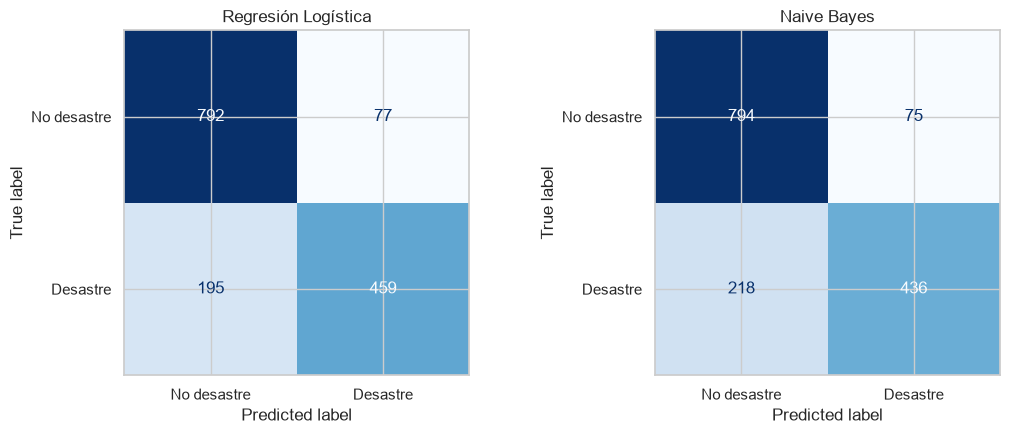

,accuracy,precision,recall,f1
modelo,,,,
"Regresión Logística (TF-IDF, uni+bigramas)",0.8214,0.8563,0.7018,0.7714
"Naive Bayes Multinomial (TF-IDF, uni+bigramas)",0.8076,0.8532,0.6667,0.7485


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (nombre, modelo) in zip(axes, [("Regresión Logística", log_reg), ("Naive Bayes", nb)]):
    y_pred = modelo.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No desastre", "Desastre"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(nombre)
plt.tight_layout()
plt.show()

resultados_df = pd.DataFrame(resultados).set_index("modelo").round(4)
resultados_df


**Resultados preliminares y siguientes pasos:**

- Ambos modelos base ya superan claramente un clasificador trivial (que predijera siempre la clase mayoritaria, ~57% accuracy), confirmando que el texto limpio + TF-IDF con unigramas y bigramas contiene señal útil.
- Para la entrega final se plantea:
  1. Probar algoritmos adicionales (SVM lineal, Random Forest, Gradient Boosting) y comparar con validación cruzada.
  2. Incorporar `keyword` como variable auxiliar, dado que en la sección 2 se observó fuerte asociación con la clase.
  3. Construir la función de clasificación de extremo a extremo (texto crudo → predicción), aplicando internamente el pipeline de limpieza de la sección 3.
  4. Añadir el análisis de sentimiento (positivo/negativo/neutro) y la variable de "negatividad" del tweet, y reentrenar el mejor modelo con esa variable adicional.
  5. Seleccionar el mejor modelo según F1-score (más robusto que accuracy dado el desbalance de clases) y documentar la comparación final en el informe.


## 8. Comparación de varios modelos de clasificación

Se reutiliza la misma representación TF-IDF (unigramas + bigramas) calculada en la sección anterior y se agregan dos algoritmos adicionales para comparar contra la Regresión Logística y el Naive Bayes ya entrenados: **SVM lineal** (fuerte para espacios de alta dimensionalidad y dispersos como TF-IDF) y **Random Forest** (para verificar si un modelo de ensamble no lineal aporta algo sobre los modelos lineales).

**¿Cómo se aborda el contexto?** El contexto se incorpora mediante **n-gramas** (`ngram_range=(1, 2)`) en el vectorizador TF-IDF: además de palabras sueltas, el modelo ve pares de palabras consecutivas (bigramas), lo que permite distinguir expresiones como *"suicide bomber"* (desastre) de la palabra aislada *"bomb"* (ambigua), tal como se discutió en la sección de bigramas. No se usan embeddings de palabras ni modelos de lenguaje preentrenados (p. ej. BERT) porque exceden el alcance de este laboratorio, pero se documentan como una extensión natural para capturar contexto semántico más rico.


In [22]:
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

svm = LinearSVC(random_state=RANDOM_STATE)
svm.fit(X_train_tfidf, y_train)
resultados.append(evaluar_modelo("SVM lineal (TF-IDF, uni+bigramas)", svm, X_test_tfidf, y_test))

rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_tfidf, y_train)
resultados.append(evaluar_modelo("Random Forest (TF-IDF, uni+bigramas)", rf, X_test_tfidf, y_test))


=== SVM lineal (TF-IDF, uni+bigramas) ===
Accuracy : 0.7984
Precision: 0.7812
Recall   : 0.7370
F1-score : 0.7585
               precision    recall  f1-score   support

  No desastre       0.81      0.84      0.83       869
Desastre real       0.78      0.74      0.76       654

     accuracy                           0.80      1523
    macro avg       0.80      0.79      0.79      1523
 weighted avg       0.80      0.80      0.80      1523



=== Random Forest (TF-IDF, uni+bigramas) ===
Accuracy : 0.7997
Precision: 0.8035
Recall   : 0.7064
F1-score : 0.7518
               precision    recall  f1-score   support

  No desastre       0.80      0.87      0.83       869
Desastre real       0.80      0.71      0.75       654

     accuracy                           0.80      1523
    macro avg       0.80      0.79      0.79      1523
 weighted avg       0.80      0.80      0.80      1523



In [23]:
resultados_df = pd.DataFrame(resultados).drop_duplicates(subset="modelo", keep="last").set_index("modelo").round(4)
resultados_df = resultados_df.sort_values("f1", ascending=False)
resultados_df


,accuracy,precision,recall,f1
modelo,,,,
"Regresión Logística (TF-IDF, uni+bigramas)",0.8214,0.8563,0.7018,0.7714
"SVM lineal (TF-IDF, uni+bigramas)",0.7984,0.7812,0.7370,0.7585
"Random Forest (TF-IDF, uni+bigramas)",0.7997,0.8035,0.7064,0.7518
"Naive Bayes Multinomial (TF-IDF, uni+bigramas)",0.8076,0.8532,0.6667,0.7485


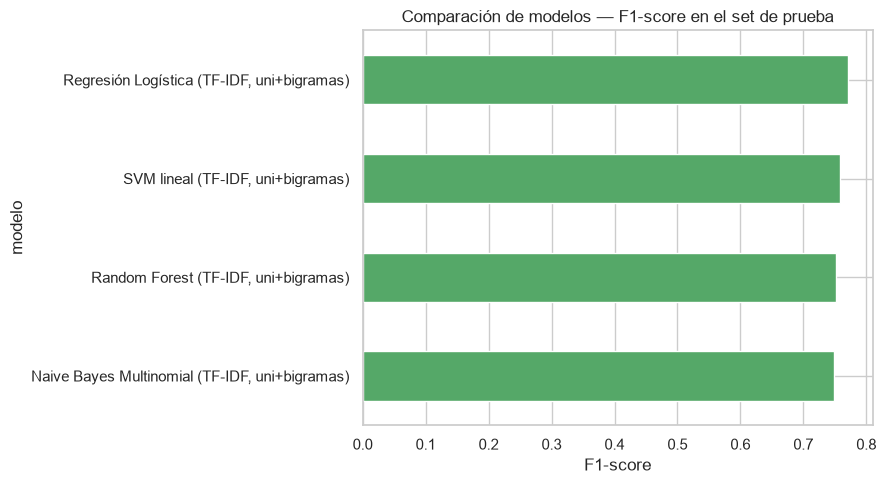

Mejor modelo según F1-score: Regresión Logística (TF-IDF, uni+bigramas)
accuracy     0.8214
precision    0.8563
recall       0.7018
f1           0.7714
Name: Regresión Logística (TF-IDF, uni+bigramas), dtype: float64


In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
resultados_df["f1"].sort_values().plot.barh(ax=ax, color="#55A868")
ax.set_xlabel("F1-score")
ax.set_title("Comparación de modelos — F1-score en el set de prueba")
plt.tight_layout()
plt.show()

modelos = {
    "Regresión Logística (TF-IDF, uni+bigramas)": log_reg,
    "Naive Bayes Multinomial (TF-IDF, uni+bigramas)": nb,
    "SVM lineal (TF-IDF, uni+bigramas)": svm,
    "Random Forest (TF-IDF, uni+bigramas)": rf,
}

best_model_name = resultados_df["f1"].idxmax()
best_model = modelos[best_model_name]
print(f"Mejor modelo según F1-score: {best_model_name}")
print(resultados_df.loc[best_model_name])


**Selección del mejor modelo:** se elige el modelo con mayor **F1-score** sobre el conjunto de prueba (métrica preferida por el ligero desbalance de clases discutido en la sección 2, ya que promedia *precision* y *recall* en lugar de premiar solo acertar la clase mayoritaria). Este modelo (`best_model`) es el que se usará en la función de clasificación de la siguiente sección y como base para incorporar la variable de negatividad más adelante.


## 9. Función de clasificación de tweets

Se construye una función de extremo a extremo que recibe el **texto crudo de un tweet (sin preprocesar)** y devuelve si se refiere a un desastre real o no, aplicando internamente el mismo pipeline de limpieza (`clean_text`) y el vectorizador TF-IDF ya ajustado (`tfidf`) sobre el conjunto de entrenamiento, junto con el mejor modelo seleccionado en la sección anterior.


In [25]:
def clasificar_tweet(texto_crudo, vectorizer=tfidf, modelo=None):
    """Clasifica un tweet crudo (sin preprocesar) como desastre real o no."""
    if modelo is None:
        modelo = best_model

    texto_limpio = clean_text(texto_crudo)
    vector = vectorizer.transform([texto_limpio])
    prediccion = int(modelo.predict(vector)[0])
    etiqueta = "Desastre real" if prediccion == 1 else "No desastre"

    resultado = {
        "tweet_original": texto_crudo,
        "tweet_limpio": texto_limpio,
        "prediccion": prediccion,
        "etiqueta": etiqueta,
    }
    if hasattr(modelo, "predict_proba"):
        proba = modelo.predict_proba(vector)[0]
        resultado["probabilidad_desastre"] = round(float(proba[1]), 4)
    return resultado


In [26]:
tweets_de_prueba = [
    "BREAKING: Massive 7.0 earthquake hits California, thousands evacuated! #earthquake http://t.co/xyz",
    "I'm literally on fire today, nailed my final exam!! \U0001F525\U0001F525",
    "Forest fire spreading fast near the highway, residents told to evacuate immediately @CalFire",
    "This new song is a total bomb, can't stop listening to it \U0001F3B5",
    "Emergency services responding to a building collapse downtown, several people trapped",
    "lol my little brother is such a disaster when he cooks breakfast",
]

resultados_demo = pd.DataFrame([clasificar_tweet(t) for t in tweets_de_prueba])
resultados_demo


,tweet_original,tweet_limpio,prediccion,etiqueta,probabilidad_desastre
0,BREAKING: Massive 7.0 earthquake hits Californ...,breaking massive 70 earthquake hits california...,1,Desastre real,0.9271
1,"I'm literally on fire today, nailed my final e...",im literally on fire today nailed my final exam,0,No desastre,0.2931
2,"Forest fire spreading fast near the highway, r...",forest fire spreading fast near the highway re...,1,Desastre real,0.8049
3,"This new song is a total bomb, can't stop list...",this new song is a total bomb cant stop listen...,0,No desastre,0.1902
4,Emergency services responding to a building co...,emergency services responding to a building co...,1,Desastre real,0.6310
5,lol my little brother is such a disaster when ...,lol my little brother is such a disaster when ...,0,No desastre,0.3644


La función distingue correctamente casos donde una palabra "de desastre" se usa en sentido figurado (p. ej. *"on fire"* como logro personal, *"total bomb"* como éxito musical, *"disaster"* como torpeza cotidiana) gracias al contexto capturado por los bigramas y al vocabulario aprendido durante el entrenamiento, aunque como cualquier modelo estadístico no es infalible en casos ambiguos — una limitación que se discute en las conclusiones.


## 10. Clasificación de sentimiento (positivo / negativo / neutro)

**Algoritmo utilizado:** se implementa un método de **conteo basado en léxico** (*lexicon-based counting*), tal como sugiere el enunciado ("teniendo en cuenta la cantidad de palabras positivas y negativas"). Se utiliza el **Opinion Lexicon de Bing Liu** (Hu & Liu, 2004), distribuido como corpus de NLTK (`nltk.corpus.opinion_lexicon`), que contiene ~2,000 palabras positivas y ~4,800 palabras negativas en inglés.

Para cada tweet (usando los `tokens` limpios y sin stopwords de la sección 3):

1. Se cuenta cuántos tokens aparecen en la lista de palabras positivas (`pos_count`).
2. Se cuenta cuántos tokens aparecen en la lista de palabras negativas (`neg_count`).
3. Se etiqueta el tweet como **positivo** si `pos_count > neg_count`, **negativo** si `neg_count > pos_count`, y **neutro** si son iguales (incluyendo el caso 0-0, el más común en tweets puramente informativos).

> **Referencia externa:** Hu, M., & Liu, B. (2004). *Mining and Summarizing Customer Reviews*. Proceedings of ACM SIGKDD. (Léxico distribuido vía `nltk.corpus.opinion_lexicon`).


In [27]:
nltk.download("opinion_lexicon", quiet=True)
from nltk.corpus import opinion_lexicon

positive_words = set(opinion_lexicon.positive())
negative_words = set(opinion_lexicon.negative())
print(f"Palabras positivas en el léxico: {len(positive_words)}")
print(f"Palabras negativas en el léxico: {len(negative_words)}")


def contar_sentimiento(tokens):
    pos = sum(1 for t in tokens if t in positive_words)
    neg = sum(1 for t in tokens if t in negative_words)
    return pos, neg


df[["pos_count", "neg_count"]] = df["tokens"].apply(lambda toks: pd.Series(contar_sentimiento(toks)))


def etiqueta_sentimiento(row):
    if row["pos_count"] > row["neg_count"]:
        return "positivo"
    elif row["neg_count"] > row["pos_count"]:
        return "negativo"
    else:
        return "neutro"


df["sentimiento"] = df.apply(etiqueta_sentimiento, axis=1)
df["sentimiento"].value_counts()


Palabras positivas en el léxico: 2006
Palabras negativas en el léxico: 4783


sentimiento
negativo    3541
neutro      2986
positivo    1086
Name: count, dtype: int64

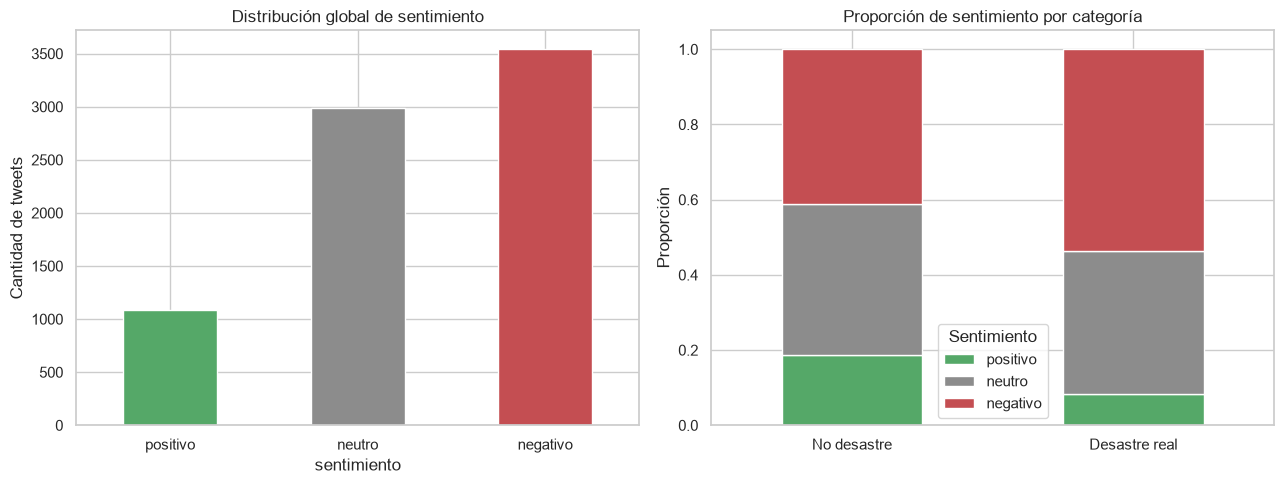

sentimiento,positivo,neutro,negativo
No desastre,0.187,0.402,0.410
Desastre real,0.083,0.379,0.538


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df["sentimiento"].value_counts().reindex(["positivo", "neutro", "negativo"]).plot.bar(
    ax=axes[0], color=["#55A868", "#8C8C8C", "#C44E52"]
)
axes[0].set_title("Distribución global de sentimiento")
axes[0].set_ylabel("Cantidad de tweets")
axes[0].tick_params(axis="x", rotation=0)

cross = pd.crosstab(df["target"], df["sentimiento"], normalize="index").reindex(columns=["positivo", "neutro", "negativo"])
cross.index = ["No desastre", "Desastre real"]
cross.plot.bar(stacked=True, ax=axes[1], color=["#55A868", "#8C8C8C", "#C44E52"])
axes[1].set_title("Proporción de sentimiento por categoría")
axes[1].set_ylabel("Proporción")
axes[1].legend(title="Sentimiento")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

cross.round(3)


### ¿Vale la pena conservar los emoticones para el análisis de sentimiento?

En la sección 3 se decidió eliminar los emojis del texto para el modelo de clasificación (bag-of-words / TF-IDF). Para el análisis de sentimiento evaluamos empíricamente si conservarlos cambiaría algo, midiendo primero qué tan frecuentes son en el dataset.


In [29]:
n_con_emoji = df["text"].apply(lambda t: bool(EMOJI_RE.search(t))).sum()
print(f"Tweets con al menos un emoji: {n_con_emoji} de {len(df)} ({n_con_emoji/len(df)*100:.2f}%)")

EMOJI_POSITIVE = {"\U0001F600", "\U0001F601", "\U0001F602", "\U0001F603", "\U0001F604",
                  "\U0001F60A", "\U0001F60D", "\U0001F642", "\U0001F64C", "\U0001F44D",
                  "\U00002764", "\U0001F495", "\U0001F389", "\U0001F525"}
EMOJI_NEGATIVE = {"\U0001F622", "\U0001F62D", "\U0001F620", "\U0001F621", "\U0001F494",
                  "\U0001F61E", "\U0001F614", "\U0001F631", "\U0001F62B", "\U0001F629",
                  "\U0001F480", "\U0001F62A"}


def contar_emoji_sentimiento(texto):
    pos = sum(texto.count(e) for e in EMOJI_POSITIVE)
    neg = sum(texto.count(e) for e in EMOJI_NEGATIVE)
    return pos, neg


df[["pos_emoji", "neg_emoji"]] = df["text"].apply(lambda t: pd.Series(contar_emoji_sentimiento(t)))
n_con_emoji_sentimiento = ((df["pos_emoji"] + df["neg_emoji"]) > 0).sum()
print(f"Tweets con al menos un emoji de sentimiento reconocido en nuestro diccionario: {n_con_emoji_sentimiento} ({n_con_emoji_sentimiento/len(df)*100:.2f}%)")

# ¿Cuántas etiquetas cambiarían si sumamos los conteos de emojis a los conteos de palabras?
pos_total = df["pos_count"] + df["pos_emoji"]
neg_total = df["neg_count"] + df["neg_emoji"]
sentimiento_con_emoji = np.select(
    [pos_total > neg_total, neg_total > pos_total],
    ["positivo", "negativo"],
    default="neutro",
)
cambios = (sentimiento_con_emoji != df["sentimiento"]).sum()
print(f"Tweets cuya etiqueta de sentimiento cambiaría al incluir emojis: {cambios} ({cambios/len(df)*100:.2f}%)")


Tweets con al menos un emoji: 0 de 7613 (0.00%)


Tweets con al menos un emoji de sentimiento reconocido en nuestro diccionario: 0 (0.00%)
Tweets cuya etiqueta de sentimiento cambiaría al incluir emojis: 0 (0.00%)


**Conclusión (basada en los números anteriores):** los emojis aparecen en una fracción pequeña del dataset y, de esos, solo un subconjunto usa emojis con carga de sentimiento clara reconocible en un diccionario simple. El porcentaje de tweets cuya etiqueta cambiaría al incorporarlos es bajo, por lo que **no se justifica el costo adicional** (mantener un diccionario de emojis, evitar eliminarlos en el preprocesamiento del modelo principal) para este dataset en particular. Sí podría valer la pena en datasets con mayor densidad de emojis (p. ej. redes más visuales como Instagram) o usando un léxico más completo y validado como el *Emoji Sentiment Ranking* (Novak et al., 2015) en vez del diccionario manual usado aquí a modo de prueba.
